# Model Training (qubit_TransmonCross_cap_matrix)
## Capacitance --> Qiskit Metal

Inverse model with surrogate-defined loss for the Transmon Cross dataset.

Instead of training the inverse model to directly predict Qiskit Metal parameters and comparing
against ground truth SQuADDS data (which penalizes valid alternative solutions), we chain the
inverse model with a frozen surrogate and compute loss in capacitance space.

**Pipeline:** Cap_input -> Inverse MLP -> Qiskit_params -> ScalerConversion -> Surrogate(frozen) -> Cap_reconstructed

**Loss:** MSE(Cap_input, Cap_reconstructed) + penalty for out-of-range predictions

The Transmon Cross dataset has all continuous parameters,
but the inverse model (ml_00/ml_01) and surrogate (ml_10/ml_11) use different scalers.
A ScalerConversionLayer handles the transform between scalers.

## Configuration

In [1]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters_surrogate_defined_loss import *
print(KERAS_TUNER_TRIALS)

248


## Library

In [2]:
import os, gc, joblib, json, time, sys, math, csv

# Disable some console warnings so you can be free of them printing. 
# Comment the next line if you want to see them
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from pandas import json_normalize
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.python.client import device_lib

In [3]:
seed = 0

# Input seed value. If this value is the same, the random number generator 
# will generate the same set of random numbers. 
tf.random.set_seed(seed)
np.random.seed(seed)

## Check GPU

In [4]:
# Look at what you are working with. If you dont have a nice GPU I highly reccomend finding one
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16951231601670805389
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 40538013696
locality {
  bus_id: 1
  links {
  }
}
incarnation: 300488259124351505
physical_device_desc: "device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:08:00.0, compute capability: 8.0"
xla_global_id: 416903419
]


I0000 00:00:1773072656.230376    1636 gpu_device.cc:2020] Created device /device:GPU:0 with 38660 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:08:00.0, compute capability: 8.0


In [5]:
# make sure something prints in the list. if it doesnt, run:
# import sys
# !{sys.executable} -m pip install -U pip
# !{sys.executable} -m pip install tensorflow[and-cuda]
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
for gpu in gpus:
    print(f'  {gpu}')

GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [6]:
# check cuda
import sys
!{sys.executable} -m pip list | egrep "tensorflow|nvidia-(cuda|cudnn|cublas|nccl)"

nvidia-cublas-cu11        11.11.3.6
nvidia-cublas-cu12        12.9.1.4
nvidia-cuda-cupti-cu11    11.8.87
nvidia-cuda-cupti-cu12    12.9.79
nvidia-cuda-nvcc-cu12     12.9.86
nvidia-cuda-nvrtc-cu11    11.8.89
nvidia-cuda-nvrtc-cu12    12.9.86
nvidia-cuda-runtime-cu11  11.8.89
nvidia-cuda-runtime-cu12  12.9.79
nvidia-cudnn-cu11         9.1.0.70
nvidia-cudnn-cu12         9.17.1.4
nvidia-nccl-cu11          2.21.5
nvidia-nccl-cu12          2.29.2
tensorflow                2.20.0
tensorflow-datasets       4.8.3+nightly
tensorflow-estimator      2.11.0
tensorflow-metadata       1.13.1


## Dataset

### Load

In [7]:
# Load the data saved from ml_00 notebook (inverse model format)
# For the transmon cross, ml_00 uses 'one_hot' encoding label but all params are continuous

# inputs are the capacitance values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_augmented.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_augmented.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# Qiskit Metal params (all continuous for transmon cross)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_augmented.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_augmented.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Capacitance):     {X_train.shape[1]} columns')
print(f'Outputs (Qiskit params):  {y_train.shape[1]} columns')
print(f'Training samples: {len(X_train)}')
print(f'\nCapacitance columns: {cap_column_names}')
print(f'Qiskit param columns: {qiskit_param_names}')

Inputs (Capacitance):     6 columns
Outputs (Qiskit params):  3 columns
Training samples: 1353

Capacitance columns: ['cross_to_ground', 'claw_to_ground', 'cross_to_claw', 'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
Qiskit param columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


In [8]:
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val   = X_val.astype('float32')
y_val   = y_val.astype('float32')
X_test  = X_test.astype('float32')
y_test  = y_test.astype('float32')

### Visualize

In [9]:
print('X_train.shape: ', X_train.shape)
print('X_val.shape:   ', X_val.shape)
print('y_train.shape: ', y_train.shape)
print('y_val.shape:   ', y_val.shape)
print('y_train[0]: ', y_train[0])

X_train.shape:  (1353, 6)
X_val.shape:    (290, 6)
y_train.shape:  (1353, 3)
y_val.shape:    (290, 3)
y_train[0]:  [0.18181819 0.         0.8484849 ]


In [10]:
display(X_train)
display(y_train)

array([[0.7970648 , 0.16781087, 0.18622357, 0.7970648 , 0.17049727,
        0.5902519 ],
       [0.9355711 , 0.11234591, 0.0357224 , 0.9355711 , 0.10241513,
        0.6549043 ],
       [0.5726175 , 0.07756818, 0.03024349, 0.5726175 , 0.07015505,
        0.40652835],
       ...,
       [0.86518973, 0.60333544, 0.60302657, 0.86518973, 0.6200695 ,
        0.7957185 ],
       [0.12103555, 0.1615095 , 0.13477261, 0.12103555, 0.16060588,
        0.14101113],
       [0.9531031 , 0.21892492, 0.22302486, 0.9531031 , 0.22153078,
        0.706829  ]], dtype=float32)

array([[0.18181819, 0.        , 0.8484849 ],
       [0.06060606, 1.        , 0.93939394],
       [0.03030303, 0.84745765, 0.57575756],
       ...,
       [0.6363636 , 0.        , 0.90909094],
       [0.12121212, 0.84745765, 0.12121212],
       [0.21212122, 0.        , 0.969697  ]], dtype=float32)

In [11]:
# Look at how it was split and decide if we like the split (we do for now)
total = len(X_train) + len(X_test) + len(X_val)
print(f'train: {len(X_train)} ({len(X_train)/total*100:.1f}%)')
print(f'val:   {len(X_val)} ({len(X_val)/total*100:.1f}%)')
print(f'test:  {len(X_test)} ({len(X_test)/total*100:.1f}%)')
print(f'total: {total}')

train: 1353 (70.0%)
val:   290 (15.0%)
test:  291 (15.0%)
total: 1934


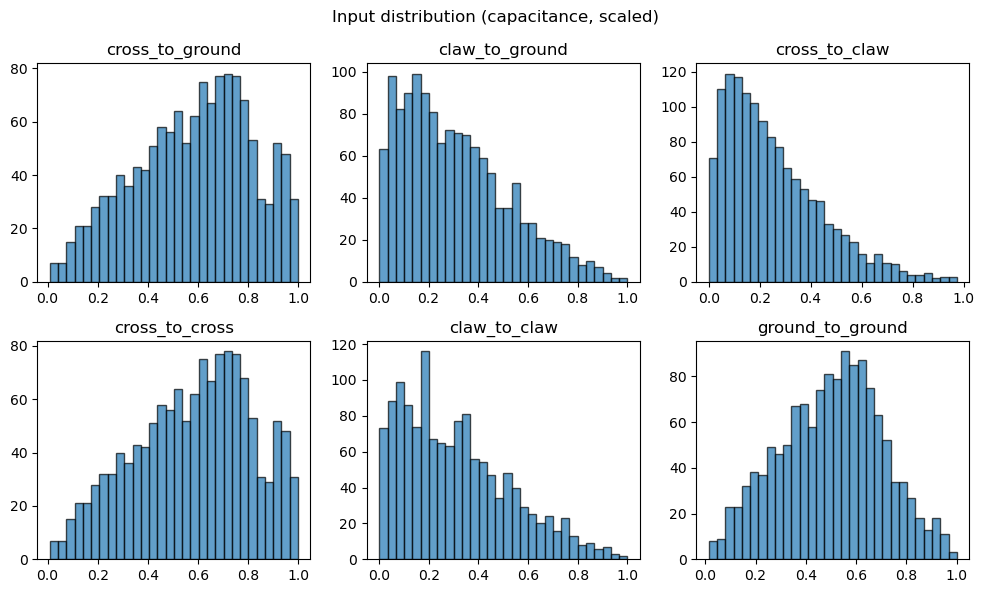

In [12]:
# Bin the input data (capacitance values) and look at distribution

num_cols = X_train.shape[1]
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()
for i in range(num_cols):
    axes[i].hist(X_train[:, i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(cap_column_names[i] if i < len(cap_column_names) else f'col_{i}')
for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Input distribution (capacitance, scaled)')
plt.tight_layout()
plt.show()

In [13]:
steps_per_epoch = int(np.ceil(len(X_train) / TRAIN_BATCH_SIZE))
LR_DECAY_STEPS = steps_per_epoch * 20   # decay every ~20 epochs
print(f'Steps per epoch: {steps_per_epoch}, LR decay steps: {LR_DECAY_STEPS}')

Steps per epoch: 11, LR decay steps: 220


## MLP

### Create model

Reccomended to download a third party app like "Sleep control Center" or "Amphetamine" to prevent computer from sleeping during training

### Make scaler conversion layer

The inverse model (ml_00/ml_01) and surrogate model (ml_10/ml_11) may use different MinMaxScalers
because they were fit on different data splits or processing pipelines.
This layer does the affine transform: `linear_scaled = oh_scaled * scale_a + scale_b`
to convert between the two scaler spaces. All operations are differentiable.

In [14]:
# Determine column mapping between inverse model output and surrogate input
# The inverse model outputs Qiskit params in ml_00 scaler space
# The surrogate expects them in ml_10 scaler space

n_qiskit_params = y_train.shape[1]
print(f'Number of Qiskit Metal params: {n_qiskit_params}')
print(f'Param names: {qiskit_param_names}')

Number of Qiskit Metal params: 3
Param names: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


In [15]:
# Compute affine conversion constants between ml_00 and ml_10 scaler spaces
# For each param: linear_scaled = oh_scaled * scale_a + scale_b
# where scale_a = oh_range / lin_range, scale_b = (oh_min - lin_min) / lin_range

scale_a = np.ones(n_qiskit_params, dtype=np.float32)
scale_b = np.zeros(n_qiskit_params, dtype=np.float32)

for i, col in enumerate(qiskit_param_names):
    # Try loading both scalers
    oh_path = f'scalers/scaler_y_{col}_one_hot_encoding.save'
    lin_path = f'scalers/scaler_y_linear_{col}.save'
    
    if os.path.exists(oh_path) and os.path.exists(lin_path):
        oh_sc  = joblib.load(oh_path)
        lin_sc = joblib.load(lin_path)
        oh_min, oh_range   = float(oh_sc.data_min_[0]), float(oh_sc.data_range_[0])
        lin_min, lin_range = float(lin_sc.data_min_[0]), float(lin_sc.data_range_[0])
        scale_a[i] = oh_range / lin_range
        scale_b[i] = (oh_min - lin_min) / lin_range
        print(f'  {col}: a={scale_a[i]:.6f}, b={scale_b[i]:.6f}')
    else:
        print(f'  {col}: using identity (missing scaler file)')

if np.allclose(scale_a, 1.0) and np.allclose(scale_b, 0.0):
    print('\nScalers are identical — conversion is identity (no transform needed)')
else:
    print('\nScalers differ — affine conversion will be applied')

  design_options.connection_pads.readout.claw_length: a=1.000000, b=0.000000
  design_options.connection_pads.readout.ground_spacing: a=1.000000, b=0.000000
  design_options.cross_length: a=1.000000, b=0.000000

Scalers are identical — conversion is identity (no transform needed)


In [16]:
# Load and freeze the surrogate model so its not updated during training
SURROGATE_PATH = 'model/best_keras_model_model2_surrogate.keras'
surrogate = load_model(SURROGATE_PATH, compile=False)

#freeze it
surrogate.trainable = False
for layer in surrogate.layers:
    layer.trainable = False

surr_input_dim = surrogate.input_shape[-1]
print(f'\nSurrogate loaded from {SURROGATE_PATH}')
print(f'Surrogate expects {surr_input_dim} inputs, inverse model outputs {n_qiskit_params}')
assert surr_input_dim == n_qiskit_params, f'Dimension mismatch!'
surrogate.summary()

I0000 00:00:1773072659.395675    1636 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38660 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:08:00.0, compute capability: 8.0



Surrogate loaded from model/best_keras_model_model2_surrogate.keras
Surrogate expects 3 inputs, inverse model outputs 3


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 352)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         2,118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,526 (13.77 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,526 (13.77 KB)

In [17]:
# Build the scaler conversion layer
# Converts inverse model output (ml_00 scaler space) to surrogate input (ml_10 scaler space)
# All operations are differentiable so gradients flow through

class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b)

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

scaler_converter = ScalerConversionLayer(
    scale_a=scale_a, scale_b=scale_b, name='scaler_conversion')

# Quick sanity test
test_input = tf.constant(y_train[:3])
test_output = scaler_converter(test_input)
print(f'Conversion test: input shape {test_input.shape} → output shape {test_output.shape}')

Conversion test: input shape (3, 3) → output shape (3, 3)


In [18]:
# Penalizes the inverse model for predicting Qiskit Metal values outside
# the training data range [0, 1] (since data is MinMaxScaled).
# This prevents the model from finding "adversarial" inputs to the surrogate
# that look good in capacitance space but don't correspond to real designs.

PENALTY_WEIGHT = 0.1  # tune this: increase if params are still wild, decrease if reconstruction suffers

def qiskit_range_penalty(y_true_dummy, y_pred):
    """Penalize predictions outside [0, 1] range.
    y_true_dummy is ignored (we pass zeros as dummy targets).
    y_pred is the inverse model's raw output in scaled space."""
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)

# Pre-build dummy targets for training
dummy_y_train = np.zeros_like(y_train)
dummy_y_val   = np.zeros_like(y_val)
dummy_y_test  = np.zeros_like(y_test)

print(f'Penalty weight: {PENALTY_WEIGHT}')
print(f'Dummy targets shape: {dummy_y_train.shape}')

Penalty weight: 0.1
Dummy targets shape: (1353, 3)


### Create Model by Hand

In [19]:
# just checkin to make sure everything looks good still, we want float32
print(X_train.dtype, X_train.shape)
print(y_train.dtype, y_train.shape)

float32 (1353, 6)
float32 (1353, 3)


In [20]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Model shape string for file naming
    model_shape = f'surrogate_loss_{X_train.shape[1]}in_{y_train.shape[1]}out'
    print(model_shape)

In [21]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Build inverse model that takes capacitance --> Qiskit Metal params
    inverse_model = Sequential(name='inverse_model')
    inverse_model.add(Input(shape=(X_train.shape[1],), name='cap_input'))
    
    for i, n in enumerate(NEURONS_PER_LAYER):
        inverse_model.add(Dense(n, name='fc{}'.format(i),
                        kernel_initializer='lecun_uniform',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        inverse_model.add(LeakyReLU(negative_slope=0.01, name='leaky_relu{}'.format(i)))
        inverse_model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name='dropout{}'.format(i)))
    
    # output layer predicts Qiskit Metal params
    inverse_model.add(Dense(y_train.shape[1], activation='linear', name='qiskit_output',
                    kernel_initializer='lecun_uniform'))
    
    # Two-output combined model:
    # Output 1: reconstructed capacitance (through frozen surrogate) — main loss
    # Output 2: raw Qiskit params — range penalty loss
    combined_input = Input(shape=(X_train.shape[1],), name='combined_input')
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = scaler_converter(predicted_qiskit)  # affine conversion
    reconstructed_cap = surrogate(predicted_qiskit_converted)
    model = Model(
        inputs=combined_input,
        outputs=[reconstructed_cap, predicted_qiskit],
        name='combined_model'
    )
    
    print('Inverse model (outputs Qiskit Metal params):')
    inverse_model.summary()
    print('\nCombined model (two outputs: cap reconstruction + Qiskit params for penalty):')
    model.summary()

In [22]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=LR_INITIAL,  
        decay_steps=LR_DECAY_STEPS,        
        decay_rate=LR_DECAY_RATE,          
        staircase=LR_STAIRCASE             
    )
    
    # Two losses: reconstruction + range penalty on Qiskit params
    model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_schedule),  
        loss=[TRAIN_LOSS, qiskit_range_penalty],
        loss_weights=[1.0, PENALTY_WEIGHT],
        metrics={model.output_names[0]: [TRAIN_LOSS]}
    )

In [23]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    !mkdir -p model
    best_model_file = 'model/{}_best_model.keras'.format(model_shape)
    last_model_file = 'model/{}_last_model.keras'.format(model_shape)
    print('Best model will be saved to:', best_model_file)

Enable training (`train_and_save`) to overwrite the model file.

In [24]:
train_and_save = True

We use Adam optimizer, minimize the loss specified in parameters, and early stop.

#### Training

In [25]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    class TrainingPlot(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.losses = []
            self.val_losses = []
        def on_epoch_end(self, epoch, logs=None):
            self.losses.append(logs.get('loss'))
            self.val_losses.append(logs.get('val_loss'))

    class LearningRateMonitor(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.learning_rates = []
        def on_epoch_end(self, epoch, logs=None):
            lr = self.model.optimizer.learning_rate
            if callable(lr):
                lr = lr(self.model.optimizer.iterations)
            self.learning_rates.append(float(tf.keras.backend.get_value(lr)))

In [26]:
%%time

# Train the model — two targets:
# 1. Cap reconstruction (input capacitance is the target)
# 2. Dummy zeros for the penalty loss (penalty only uses predictions, ignores target)
history = None  
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    if train_and_save: 
        early_stopping = EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE,
            verbose=1
        )
    
        plot_callback = TrainingPlot()
        lr_monitor = LearningRateMonitor()
        
        model_checkpoint = ModelCheckpoint(
            filepath=best_model_file,          
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=0
        )

        history = model.fit(
            np.asarray(X_train),
            [np.asarray(X_train), dummy_y_train],
            epochs=400,                   
            batch_size=TRAIN_BATCH_SIZE,  
            validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),  
            callbacks=[early_stopping, model_checkpoint, plot_callback, lr_monitor],  
            verbose=1
        )
        
        model.save(last_model_file)

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 13.8 μs


Load the saved best model and use it from now on.

In [27]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    model = load_model(best_model_file, custom_objects={
        'ScalerConversionLayer': ScalerConversionLayer,
        'qiskit_range_penalty': qiskit_range_penalty})

### Sweep total number of parameters to find the right range

In [28]:
if SWEEP_PARAM_NUM:
    qiskit_dim = y_train.shape[1]
    cap_dim = X_train.shape[1]
    
    def build_combined_mlp(neurons_per_layer):
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(cap_dim,), name='cap_input'))
        for i, n in enumerate(neurons_per_layer):
            inv.add(Dense(n, name=f'fc{i}', kernel_initializer='lecun_uniform',
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=TRAIN_DROPOUT_RATE, name=f'dropout{i}'))
        inv.add(Dense(qiskit_dim, activation='linear', name='qiskit_output',
                        kernel_initializer='lecun_uniform'))
        combined_input = Input(shape=(cap_dim,))
        qiskit_out = inv(combined_input)
        qiskit_conv = scaler_converter(qiskit_out)
        cap_recon = surrogate(qiskit_conv)
        return Model(combined_input, [cap_recon, qiskit_out])
    
    def make_optimizer():
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=LR_INITIAL,
            decay_steps=LR_DECAY_STEPS,
            decay_rate=LR_DECAY_RATE,
            staircase=LR_STAIRCASE)
        return tf.optimizers.Adam(learning_rate=lr_schedule)
    
    def train_one_config(neurons_per_layer, seed=0):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        global surrogate, scaler_converter
        surrogate = load_model(SURROGATE_PATH, compile=False)
        surrogate.trainable = False
        for layer in surrogate.layers:
            layer.trainable = False
        scaler_converter = ScalerConversionLayer(
            scale_a=scale_a, scale_b=scale_b, name='scaler_conversion')
        combined = build_combined_mlp(neurons_per_layer)
        combined.compile(optimizer=make_optimizer(),
                        loss=[TRAIN_LOSS, qiskit_range_penalty],
                        loss_weights=[1.0, PENALTY_WEIGHT])
        early_stopping = EarlyStopping(
            monitor='val_loss', mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=0,
            restore_best_weights=True)
        history = combined.fit(
            np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
            validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
            epochs=400, batch_size=TRAIN_BATCH_SIZE,
            callbacks=[early_stopping], verbose=0)
        best_val = min(history.history['val_loss'])
        return combined, history, best_val

### Sweep amount of data used in training

In [29]:
if SWEEP_DATA_AMOUNT:
    FIXED_DEPTH = 1
    FIXED_WIDTH = 1024
    FIXED_NEURONS = [FIXED_WIDTH] * FIXED_DEPTH
    print(f'Sweep data amount with fixed architecture: {FIXED_NEURONS}')

### Keras Tuner to Find Best Hyperparameters

Run this if you want to use keras tuner to make the model rather than doing it by hand

In [30]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, Input
    from keras_tuner import BayesianOptimization
    import keras_tuner as kt

In [31]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    cap_dim = X_train.shape[1]
    qiskit_dim = y_train.shape[1]
    
    def build_hypermodel(hp):
        tf.keras.backend.clear_session()
        gc.collect()
        
        # reload surrogate + rebuild conversion layer after clear_session
        surr = load_model(SURROGATE_PATH, compile=False)
        surr.trainable = False
        for layer in surr.layers:
            layer.trainable = False
        converter = ScalerConversionLayer(
            scale_a=scale_a, scale_b=scale_b, name='scaler_conversion')
        
        n_layers = hp.Int('n_layers', min_value=1, max_value=4, default=2)
        neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=64, max_value=1024, step=64) for i in range(n_layers)]
        dropout_rate = hp.Float('dropout_rate', 0.0, 0.3, step=0.05)
        l2_reg = hp.Float('l2_reg', 1e-6, 1e-2, sampling='LOG', default=1e-4)
        lr_initial = hp.Float('learning_rate', 1e-3, 1e-1, sampling='LOG', default=1e-2)
        use_batchnorm = hp.Boolean('use_batchnorm', default=True)
        penalty_wt = hp.Float('penalty_weight', 0.01, 1.0, sampling='LOG', default=0.1)
        
        # build the inverse model
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(cap_dim,), name='cap_input'))
        for i, n_units in enumerate(neurons_per_layer):
            inv.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                inv.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        inv.add(Dense(qiskit_dim, name='qiskit_output', kernel_initializer='he_normal'))
        
        # Two-output model
        combined_input = Input(shape=(cap_dim,), name='combined_input')
        qiskit_out = inv(combined_input)
        qiskit_conv = converter(qiskit_out)
        cap_recon = surr(qiskit_conv)
        combined = Model(combined_input, [cap_recon, qiskit_out], name='combined_model')
        combined.compile(
            optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, penalty_wt],
        )
        return combined

In [32]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner = BayesianOptimization(
        build_hypermodel,
        objective='val_loss',
        max_trials=KERAS_TUNER_TRIALS,
        seed=seed,
        directory='kt_dir',
        project_name='transmon_cross_surrogate_loss'
    )

Reloading Tuner from kt_dir/transmon_cross_surrogate_loss/tuner0.json


In [33]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    early_stopping = EarlyStopping(
        monitor='val_loss', mode='min',
        patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=1)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

In [34]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner.search(
        np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

Trial 248 Complete [00h 00m 53s]
val_loss: 0.010535897687077522

Best val_loss So Far: 0.0043407767079770565
Total elapsed time: 1d 13h 57m 09s


In [35]:
encoding = 'surrogate_defined_loss'
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    os.makedirs('model', exist_ok=True)
    best_model_file = f'model/best_keras_model_{encoding}.keras'
    best_combined = tuner.get_best_models(1)[0]
    best_combined.save(best_model_file)
    
    inverse_only = best_combined.get_layer('inverse_model')
    inverse_only.save(f'model/best_inverse_model_{encoding}.keras')
    print(f'Saved combined model: {best_model_file}')
    print(f'Saved inverse-only model: model/best_inverse_model_{encoding}.keras')
    
    tf.keras.backend.clear_session()
    gc.collect()
    with tf.device('/CPU:0'):
        loaded_model = load_model(best_model_file, compile=False,
                                  custom_objects={'ScalerConversionLayer': ScalerConversionLayer})

/home/olivias/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved combined model: model/best_keras_model_surrogate_defined_loss.keras
Saved inverse-only model: model/best_inverse_model_surrogate_defined_loss.keras


### View the model

In [36]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('Combined model (inverse + conversion + frozen surrogate):')
    best_combined.summary()

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('Combined model:')
    model.summary()

Combined model (inverse + conversion + frozen surrogate):


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │           643 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │         3,526 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,169 (16.29 KB)

 Trainable params: 643 (2.51 KB)

 Non-trainable params: 3,526 (13.77 KB)

### Evaluation

Plot training history.

### Visualize gradients for best model

In [37]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    class GradientNormLogger(tf.keras.callbacks.Callback):
        def __init__(self, x_probe, y_probe, layer_name_prefixes=('fc0',), log_every=1, verbose=0):
            super().__init__()
            self.x_probe = x_probe
            self.y_probe = y_probe
            self.prefixes = layer_name_prefixes
            self.log_every = log_every
            self.verbose = verbose
            self.records = []
        def on_epoch_end(self, epoch, logs=None):
            if epoch % self.log_every != 0: return
            with tf.GradientTape() as tape:
                preds = self.model(self.x_probe, training=True)
                loss = self.model.compute_loss(self.x_probe, self.y_probe, preds)
            grads = tape.gradient(loss, self.model.trainable_variables)
            rec = {'epoch': epoch, 'loss': float(loss)}
            for var, g in zip(self.model.trainable_variables, grads):
                if g is None: continue
                for pfx in self.prefixes:
                    if pfx in var.name:
                        rec[f'grad_norm_{var.name}'] = float(tf.norm(g))
            self.records.append(rec)
        def to_csv(self, path):
            pd.DataFrame(self.records).to_csv(path, index=False)

In [38]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    probe_n = min(256, len(X_train))
    x_probe = np.asarray(X_train[:probe_n])
    y_probe = [np.asarray(X_train[:probe_n]), np.zeros((probe_n, y_train.shape[1]), dtype='float32')]
    grad_logger = GradientNormLogger(x_probe=x_probe, y_probe=y_probe,
        layer_name_prefixes=('fc0', 'qiskit_output'), log_every=1, verbose=1)
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    history = model.fit(
        np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
        callbacks=[early_stopping, lr_monitor, grad_logger], verbose=1)
    grad_logger.to_csv(f'plots/{encoding}_gradients.csv')
    del model; tf.keras.backend.clear_session(); gc.collect()

In [39]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    dfg = pd.DataFrame(grad_logger.records)
    plt.figure(figsize=(12, 4))
    for col in dfg.columns:
        if col.startswith('grad_norm_'):
            plt.plot(dfg['epoch'], dfg[col], label=col.replace('grad_norm_', ''))
    plt.xlabel('Epoch'); plt.ylabel('Gradient Norm'); plt.legend(fontsize=6)
    plt.title('Gradient norms during training'); plt.tight_layout()
    plt.savefig(f'plots/{encoding}_gradient_norms.pdf'); plt.show()

### Look at best model

Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - inverse_model_loss: 0.0721 - loss: 0.3781 - sequential_loss: 0.3701 - val_inverse_model_loss: 0.0370 - val_loss: 0.1870 - val_sequential_loss: 0.1834
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - inverse_model_loss: 0.0049 - loss: 0.0971 - sequential_loss: 0.0955 - val_inverse_model_loss: 3.6366e-04 - val_loss: 0.0646 - val_sequential_loss: 0.0638
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - inverse_model_loss: 0.0016 - loss: 0.0523 - sequential_loss: 0.0520 - val_inverse_model_loss: 2.6081e-04 - val_loss: 0.0432 - val_sequential_loss: 0.0412
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - inverse_model_loss: 1.4491e-04 - loss: 0.0352 - sequential_loss: 0.0347 - val_inverse_model_loss: 5.6137e-05 - val_loss: 0.0346 - val_sequential_loss: 0.0334
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - inverse_model_loss: 2.8416e-05 - loss: 0.0278 - sequential_loss: 0.0274 - val_inverse_model_loss: 1.7184e-05 - va

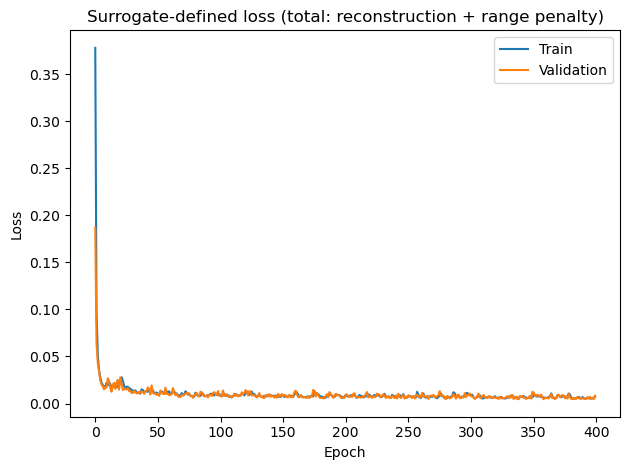

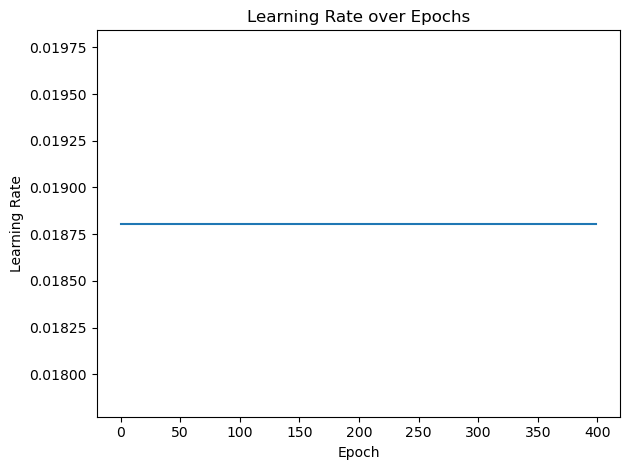

In [41]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and not VISUALIZE_GRADIENTS:
    class LearningRateMonitor(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.learning_rates = []
        def on_epoch_end(self, epoch, logs=None):
            lr = self.model.optimizer.learning_rate
            if callable(lr):
                lr = lr(self.model.optimizer.iterations)
            self.learning_rates.append(float(tf.keras.backend.get_value(lr)))

    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    history = model.fit(
        np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
        callbacks=[early_stopping, lr_monitor], verbose=1)
    del model; tf.keras.backend.clear_session(); gc.collect()

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Surrogate-defined loss (total: reconstruction + range penalty)')
plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.tight_layout(); plt.savefig(f'plots/surrogate_loss_history.pdf'); plt.show()

plt.plot(lr_monitor.learning_rates)
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.tight_layout(); plt.savefig(f'plots/surrogate_loss_learning_rate.pdf'); plt.show()

### Test set evaluation

In [42]:
# Evaluate on test set
tf.keras.backend.clear_session()
gc.collect()

def get_loss(eval_out):
    if isinstance(eval_out, dict):
        return float(eval_out.get('loss', list(eval_out.values())[0]))
    if isinstance(eval_out, (list, tuple, np.ndarray)):
        return float(eval_out[0])
    return float(eval_out)

combined_model = load_model(best_model_file, compile=False,
    custom_objects={'ScalerConversionLayer': ScalerConversionLayer})
combined_model.compile(optimizer='adam',
    loss=[TRAIN_LOSS, qiskit_range_penalty],
    loss_weights=[1.0, PENALTY_WEIGHT])
eval_result = combined_model.evaluate(
    np.asarray(X_test), [np.asarray(X_test), dummy_y_test])
total_loss = float(eval_result[0])
cap_recon_loss = float(eval_result[1])
penalty_loss = float(eval_result[2])

print(f'Total test loss: {total_loss}')
print(f'  Reconstruction loss ({TRAIN_LOSS}): {cap_recon_loss}')
print(f'  Range penalty loss: {penalty_loss} (weighted: {penalty_loss * PENALTY_WEIGHT})')

# Check out-of-range
inverse_model = combined_model.get_layer('inverse_model')
qiskit_pred = inverse_model.predict(np.asarray(X_test), verbose=0)
out_of_range = np.sum((qiskit_pred < 0) | (qiskit_pred > 1))
total_values = qiskit_pred.size
print(f'Out-of-range values: {out_of_range}/{total_values} ({100*out_of_range/total_values:.1f}%)')

test_loss_result = cap_recon_loss

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - inverse_model_loss: 1.4824e-06 - loss: 0.0043 - sequential_loss: 0.0043
Total test loss: 0.004306318238377571
  Reconstruction loss (mae): 0.004306368064135313
  Range penalty loss: 1.4824441905147978e-06 (weighted: 1.482444190514798e-07)
Out-of-range values: 15/873 (1.7%)


## Compare predictions vs. test set

In [43]:
csv_data = [[
    DATA_AUGMENTATION,
    'surrogate_loss_model',
    'InverseModel_SurrogateLoss',
    test_loss_result,
    TRAIN_LOSS,
    TRAIN_BATCH_SIZE,
]]
with open('test_results.csv', 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(csv_data)
    print(f'Appended to test_results.csv: {csv_data}')

Appended to test_results.csv: [[True, 'surrogate_loss_model', 'InverseModel_SurrogateLoss', 0.004306368064135313, 'mae', 128]]


In [44]:
# predictaroo on test set
tf.keras.backend.clear_session()
gc.collect()

with tf.device('/CPU:0'):
    combined_model = load_model(best_model_file, compile=False,
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer})
    predictions = combined_model.predict(np.asarray(X_test), verbose=0)
    if isinstance(predictions, list):
        cap_reconstructed = predictions[0]
        qiskit_predicted = predictions[1]
    else:
        cap_reconstructed = predictions
        inverse_model = combined_model.get_layer('inverse_model')
        qiskit_predicted = inverse_model.predict(np.asarray(X_test), verbose=0)

In [45]:
# look at how well the reconstructed capacitance matches the input capacitance

X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)  # ground truth Qiskit params (for reference)
cap_recon  = np.asarray(cap_reconstructed)
qiskit_pred = np.asarray(qiskit_predicted)

n_samples, n_cap_cols = X_test_cur.shape
n_qiskit_cols = qiskit_pred.shape[1]
n_samples_to_show = 3

# reconstruction errors (capacitance space — this is what we trained on)
cap_abs_errors = np.abs(X_test_cur - cap_recon)

print('########## Capacitance Reconstruction (what the loss is based on) #############')
for i in range(n_samples_to_show):
    rows = []
    for j in range(n_cap_cols):
        label = cap_column_names[j] if j < len(cap_column_names) else f'cap_col_{j}'
        rows.append({'param': label, 'ref': X_test_cur[i,j],
                     'pred': cap_recon[i,j], 'abs_error': cap_abs_errors[i,j]})
    print(f'— Sample {i} — Capacitance reconstruction (scaled)')
    print(pd.DataFrame(rows).to_string(index=False))
    
    # predicted Qiskit params
    print(f'\n  Predicted Qiskit Metal params (scaled):')
    for j, col_name in enumerate(qiskit_param_names):
        short = col_name.replace('design_options.', '')
        print(f'    {short:40s}  pred={qiskit_pred[i,j]:.6f}  ref={y_test_cur[i,j]:.6f}  err={abs(qiskit_pred[i,j]-y_test_cur[i,j]):.6f}')
    print()

########## Capacitance Reconstruction (what the loss is based on) #############
— Sample 0 — Capacitance reconstruction (scaled)
           param      ref     pred  abs_error
 cross_to_ground 0.491077 0.491418   0.000341
  claw_to_ground 0.333713 0.334445   0.000732
   cross_to_claw 0.324772 0.323355   0.001417
  cross_to_cross 0.491077 0.491276   0.000199
    claw_to_claw 0.339820 0.340507   0.000686
ground_to_ground 0.450407 0.445164   0.005243

  Predicted Qiskit Metal params (scaled):
    connection_pads.readout.claw_length       pred=0.331977  ref=0.333333  err=0.001356
    connection_pads.readout.ground_spacing    pred=0.173922  ref=0.152542  err=0.021380
    cross_length                              pred=0.518445  ref=0.515152  err=0.003293

— Sample 1 — Capacitance reconstruction (scaled)
           param      ref     pred  abs_error
 cross_to_ground 0.572236 0.571610   0.000626
  claw_to_ground 0.119324 0.117430   0.001894
   cross_to_claw 0.050609 0.061260   0.010652
  cross_

### Unscaled test vs predictions

In [46]:
# Unscale everything and look at errors in real units that we can actually make sense of
with open('X_names', 'r') as f:
    cap_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

# Unscale input capacitance
x_scaler_prefix = 'scaler_X'
X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale reconstructed capacitance
cap_recon_unscaled = np.asarray(cap_recon.copy())
for i in range(cap_recon_unscaled.shape[0]):
    for j in range(cap_recon_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        cap_recon_unscaled[i, j] = scaler.inverse_transform([[cap_recon_unscaled[i, j]]])[0][0]

# Unscale Qiskit param predictions (using ml_00 one_hot scalers)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_y_{col_name}_one_hot_encoding.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

n_samples_to_show = 3
cap_abs_unscaled = np.abs(X_test_unscaled - cap_recon_unscaled)

print('########## Unscaled Capacitance Reconstruction #############')
for i in range(n_samples_to_show):
    rows = []
    for j in range(X_test_unscaled.shape[1]):
        rows.append({'param': cap_names[j], 'ref_unscaled': X_test_unscaled[i,j],
                     'pred_unscaled': cap_recon_unscaled[i,j], 'abs_error': cap_abs_unscaled[i,j]})
    print(f'— Sample {i} (Unscaled) — Capacitance reconstruction')
    print(pd.DataFrame(rows).to_string(index=False))
    
    print(f'\n  Predicted Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short = col_name.replace('design_options.', '')
        print(f'    {short:40s}  pred={qiskit_pred_unscaled[i,j]:.6f}  ref={y_test_unscaled[i,j]:.6f}  err={abs(qiskit_pred_unscaled[i,j]-y_test_unscaled[i,j]):.6f}')
    
    print(f'\n  Reference Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short = col_name.replace('design_options.', '')
        print(f'    {short:40s}  ref={y_test_unscaled[i,j]:.6f}')
    print()

print('Unscaled cap reconstruction error stats:')
print('  min:', float(cap_abs_unscaled.min()),
      ' median:', float(np.median(cap_abs_unscaled)),
      ' max:', float(cap_abs_unscaled.max()))

########## Unscaled Capacitance Reconstruction #############
— Sample 0 (Unscaled) — Capacitance reconstruction
           param  ref_unscaled  pred_unscaled  abs_error
 cross_to_ground    133.517151     133.581512   0.064362
  claw_to_ground     96.702980      96.794426   0.091446
   cross_to_claw      5.987050       5.967897   0.019153
  cross_to_cross    133.517151     133.554718   0.037567
    claw_to_claw    103.122643     103.214592   0.091949
ground_to_ground    287.806000     286.044098   1.761902

  Predicted Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       pred=0.000180  ref=0.000180  err=0.000000
    connection_pads.readout.ground_spacing    pred=0.000005  ref=0.000005  err=0.000000
    cross_length                              pred=0.000261  ref=0.000260  err=0.000001

  Reference Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       ref=0.000180
    connection_pads.readout.ground_spacing    ref=0.000005
    cross_length 